In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("455_61_68_flipkart.csv")

In [4]:
df.head()

,product name,Price,rating,features,pagenum,original_price,Discount,Review
0,HP MSO 2024 Intel Core i3 13th Gen 1315U - (16...,"₹42,990",4.2,Intel Core i3 Processor (13th Gen)16 GB DDR4 R...,1,"₹50,903",15% off,"2,769 Ratings & 162 Reviews"
1,HP HyperX Omen Intel Core i7 14th Gen 14650 HX...,"₹1,49,990",4.2,Intel Core i7 Processor (14th Gen)24 GB DDR5 R...,1,"₹1,59,624",6% off,28 Ratings & 5 Reviews
2,ZEBRONICS Pro Series Z Intel Core i7 12th Gen ...,"₹32,499",4.0,Intel Core i7 Processor (12th Gen)16 GB DDR4 R...,1,"₹78,999",58% off,315 Ratings & 30 Reviews
3,Lenovo 100e Chromebook Gen 4 MediaTek Kompanio...,"₹10,999",4.0,MediaTek Kompanio 520 Processor4 GB LPDDR4X RA...,1,"₹16,298",32% off,"2,486 Ratings & 184 Reviews"
4,Acer Aspire 3 Intel Celeron Dual Core - (8 GB/...,"₹23,500",3.8,Intel Celeron Dual Core Processor8 GB DDR4 RAM...,1,"₹30,500",22% off,"8,473 Ratings & 732 Reviews"


In [5]:
df.tail()

,product name,Price,rating,features,pagenum,original_price,Discount,Review
979,HP Pavilion Plus Intel Core i5 13th Gen 13500H...,"₹84,990",NaN,Intel Core i5 Processor (13th Gen)16 GB LPDDR5...,41,"₹1,18,592",28% off,NaN
980,HP HyperX Omen Intel Core i7 14th Gen 14650 HX...,"₹1,59,990",4.7,Intel Core i7 Processor (14th Gen)24 GB DDR5 R...,41,"₹1,70,865",6% off,6 Ratings & 1 Reviews
981,HP Pavilion Plus Metal Body Intel Core i5 13th...,"₹64,990",NaN,Intel Core i5 Processor (13th Gen)16 GB DDR5 R...,41,"₹92,746",29% off,NaN
982,ASUS Vivobook Go 15 Intel Celeron Dual Core N4...,"₹39,990",3.9,Intel Celeron Dual Core Processor8 GB DDR4 RAM...,41,NaN,NaN,"1,534 Ratings & 136 Reviews"
983,HP Laptop Intel Core i3 12th Gen 1215U - (8 GB...,"₹38,900",NaN,Intel Core i3 Processor (12th Gen)8 GB DDR4 RA...,41,"₹46,706",16% off,NaN


In [6]:
df.describe()

,rating,pagenum
count,763.000000,984.000000
mean,4.245740,21.000000
std,0.331294,11.838176
min,1.000000,1.000000
25%,4.200000,11.000000
50%,4.200000,21.000000
75%,4.400000,31.000000
max,5.000000,41.000000


In [8]:
df["product name"]

0      HP MSO 2024 Intel Core i3 13th Gen 1315U - (16...
1      HP HyperX Omen Intel Core i7 14th Gen 14650 HX...
2      ZEBRONICS Pro Series Z Intel Core i7 12th Gen ...
3      Lenovo 100e Chromebook Gen 4 MediaTek Kompanio...
4      Acer Aspire 3 Intel Celeron Dual Core - (8 GB/...
                             ...                        
979    HP Pavilion Plus Intel Core i5 13th Gen 13500H...
980    HP HyperX Omen Intel Core i7 14th Gen 14650 HX...
981    HP Pavilion Plus Metal Body Intel Core i5 13th...
982    ASUS Vivobook Go 15 Intel Celeron Dual Core N4...
983    HP Laptop Intel Core i3 12th Gen 1215U - (8 GB...
Name: product name, Length: 984, dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product name    984 non-null    object 
 1   Price           984 non-null    object 
 2   rating          763 non-null    float64
 3   features        984 non-null    object 
 4   pagenum         984 non-null    int64  
 5   original_price  933 non-null    object 
 6   Discount        924 non-null    object 
 7   Review          763 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 61.6+ KB


In [10]:
df.isnull().sum()

product name        0
Price               0
rating            221
features            0
pagenum             0
original_price     51
Discount           60
Review            221
dtype: int64

In [12]:
df["rating"].value_counts()

4.2    242
4.3    142
4.4     74
4.1     68
4.7     58
3.9     30
4.0     25
4.5     22
3.8     21
5.0     14
4.8     13
4.6     12
3.7     12
4.9      8
3.3      6
3.6      5
3.1      3
3.4      2
3.5      1
3.0      1
2.0      1
1.0      1
2.3      1
2.8      1
Name: rating, dtype: int64

In [13]:
df["rating"].mode()[0]

4.2

In [14]:
df["rating"].fillna(df["rating"].mode()[0],inplace = True)

In [15]:
df["original_price"].fillna(df["original_price"].mode()[0],inplace = True)

In [16]:
df["Discount"].fillna(df["Discount"].mode()[0],inplace = True)

In [17]:
df["Review"].fillna(df["Review"].mode()[0],inplace = True)

In [18]:
df.isnull().sum()

product name      0
Price             0
rating            0
features          0
pagenum           0
original_price    0
Discount          0
Review            0
dtype: int64

In [19]:
df.duplicated().sum()

0

In [ ]:
# df.drop_duplicates(inplace=True) -- > if we have duplicated we need to do this

In [22]:
df["product name"].apply(lambda x:re.findall(r"^\w",x))

0      [H]
1      [H]
2      [Z]
3      [L]
4      [A]
      ... 
979    [H]
980    [H]
981    [H]
982    [A]
983    [H]
Name: product name, Length: 984, dtype: object

In [23]:
df["product name"].apply(lambda x:re.findall(r"^\w+",x))

0             [HP]
1             [HP]
2      [ZEBRONICS]
3         [Lenovo]
4           [Acer]
          ...     
979           [HP]
980           [HP]
981           [HP]
982         [ASUS]
983           [HP]
Name: product name, Length: 984, dtype: object

In [24]:
df["product name"].apply(lambda x:re.findall(r"^\w+",x)[0])

0             HP
1             HP
2      ZEBRONICS
3         Lenovo
4           Acer
         ...    
979           HP
980           HP
981           HP
982         ASUS
983           HP
Name: product name, Length: 984, dtype: object

In [25]:
df["Brand"] = df["product name"].apply(lambda x:re.findall(r"^\w+",x)[0])

In [27]:
df["Brand"]

0             HP
1             HP
2      ZEBRONICS
3         Lenovo
4           Acer
         ...    
979           HP
980           HP
981           HP
982         ASUS
983           HP
Name: Brand, Length: 984, dtype: object

In [30]:
df["processor"] = df["features"].apply(lambda x:re.findall(r"^\w+",x)[0])

In [31]:
df.head(1)

,product name,Price,rating,features,pagenum,original_price,Discount,Review,Brand,processor
0,HP MSO 2024 Intel Core i3 13th Gen 1315U - (16...,"₹42,990",4.2,Intel Core i3 Processor (13th Gen)16 GB DDR4 R...,1,"₹50,903",15% off,"2,769 Ratings & 162 Reviews",HP,Intel


In [34]:
df["Price"] = df["Price"].apply(lambda x:re.sub(r"[₹,]","",x)).astype("int")

In [36]:
df["original_price"] = df["original_price"].apply(lambda x:re.sub(r"[₹,]","",x)).astype("int")

In [40]:
df["Rating1"] = df["Review"].apply(lambda x:re.split(r"[&]",x)[0])

In [42]:
df["no_of_ratings"] = df["Rating1"].apply(lambda x:re.findall(r"[\d,]+",x)[0].replace(",","")).astype("int")

In [44]:
df["Reviews1"] = df["Review"].apply(lambda x:re.split(r"[&]",x)[1])

In [46]:
df["no_of_reviews"] = df["Reviews1"].apply(lambda x:re.findall(r"[\d,]+",x)[0].replace(",","")).astype("int")

In [48]:
df["Discount"] = df["Discount"].apply(lambda x:re.findall(r"[\d%]+",x)[0])

In [53]:
df["GB_List"] = df["features"].apply(lambda x:re.findall(r"(\d+)\s*GB",x))

In [55]:
df["GB_List"].apply(lambda x:x[0] if len(x)>0 else np.nan)

0      16
1      24
2      16
3       4
4       8
       ..
979    16
980    24
981    16
982     8
983     8
Name: GB_List, Length: 984, dtype: object

In [57]:
df["RAM"] = df["GB_List"].apply(lambda x:x[0] if len(x)>0 else np.nan).astype("int") # for change dtype -- int

In [59]:
df["Storage"] = df["GB_List"].apply(lambda x:x[1] if len(x)>1 else np.nan)

In [60]:
df["Storage"].isnull().sum()

200

In [61]:
df["Storage"].value_counts()

512    743
256     38
128      3
Name: Storage, dtype: int64

In [62]:
df["Storage"].fillna(df["Storage"].mode()[0],inplace = True)

In [64]:
df["Storage"] = df["Storage"].astype("int")

In [66]:
df.shape

(984, 17)

In [67]:
df.columns

Index(['product name', 'Price', 'rating', 'features', 'pagenum',
       'original_price', 'Discount', 'Review', 'Brand', 'processor', 'Rating1',
       'no_of_ratings', 'Reviews1', 'no_of_reviews', 'GB_List', 'RAM',
       'Storage'],
      dtype='object')

In [69]:
df.drop(columns = {'product name', 'features', 'Review', 'Rating1', 'Reviews1','GB_List'},inplace = True)

In [70]:
df

,Price,rating,pagenum,original_price,Discount,Brand,processor,no_of_ratings,no_of_reviews,RAM,Storage
0,42990,4.2,1,50903,15%,HP,Intel,2769,162,16,512
1,149990,4.2,1,159624,6%,HP,Intel,28,5,24,512
2,32499,4.0,1,78999,58%,ZEBRONICS,Intel,315,30,16,512
3,10999,4.0,1,16298,32%,Lenovo,MediaTek,2486,184,4,512
4,23500,3.8,1,30500,22%,Acer,Intel,8473,732,8,512
...,...,...,...,...,...,...,...,...,...,...,...
979,84990,4.2,41,118592,28%,HP,Intel,2769,162,16,512
980,159990,4.7,41,170865,6%,HP,Intel,6,1,24,512
981,64990,4.2,41,92746,29%,HP,Intel,2769,162,16,512
982,39990,3.9,41,99990,15%,ASUS,Intel,1534,136,8,512


In [71]:
df.isnull().sum()

Price             0
rating            0
pagenum           0
original_price    0
Discount          0
Brand             0
processor         0
no_of_ratings     0
no_of_reviews     0
RAM               0
Storage           0
dtype: int64

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Price           984 non-null    int32  
 1   rating          984 non-null    float64
 2   pagenum         984 non-null    int64  
 3   original_price  984 non-null    int32  
 4   Discount        984 non-null    object 
 5   Brand           984 non-null    object 
 6   processor       984 non-null    object 
 7   no_of_ratings   984 non-null    int32  
 8   no_of_reviews   984 non-null    int32  
 9   RAM             984 non-null    int32  
 10  Storage         984 non-null    int32  
dtypes: float64(1), int32(6), int64(1), object(3)
memory usage: 61.6+ KB


In [73]:
df.to_csv("cleaned_flipkart.csv",index = False)

In [74]:
df = pd.read_csv("cleaned_flipkart.csv")
df

,Price,rating,pagenum,original_price,Discount,Brand,processor,no_of_ratings,no_of_reviews,RAM,Storage
0,42990,4.2,1,50903,15%,HP,Intel,2769,162,16,512
1,149990,4.2,1,159624,6%,HP,Intel,28,5,24,512
2,32499,4.0,1,78999,58%,ZEBRONICS,Intel,315,30,16,512
3,10999,4.0,1,16298,32%,Lenovo,MediaTek,2486,184,4,512
4,23500,3.8,1,30500,22%,Acer,Intel,8473,732,8,512
...,...,...,...,...,...,...,...,...,...,...,...
979,84990,4.2,41,118592,28%,HP,Intel,2769,162,16,512
980,159990,4.7,41,170865,6%,HP,Intel,6,1,24,512
981,64990,4.2,41,92746,29%,HP,Intel,2769,162,16,512
982,39990,3.9,41,99990,15%,ASUS,Intel,1534,136,8,512


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Price           984 non-null    int64  
 1   rating          984 non-null    float64
 2   pagenum         984 non-null    int64  
 3   original_price  984 non-null    int64  
 4   Discount        984 non-null    object 
 5   Brand           984 non-null    object 
 6   processor       984 non-null    object 
 7   no_of_ratings   984 non-null    int64  
 8   no_of_reviews   984 non-null    int64  
 9   RAM             984 non-null    int64  
 10  Storage         984 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 84.7+ KB


In [76]:
df.isnull().sum()

Price             0
rating            0
pagenum           0
original_price    0
Discount          0
Brand             0
processor         0
no_of_ratings     0
no_of_reviews     0
RAM               0
Storage           0
dtype: int64

In [77]:
df.duplicated().sum()

2

In [78]:
df.drop_duplicates(inplace=True)

In [79]:
df.duplicated().sum()

0

In [80]:
## Univariate Analysis

<Axes: >

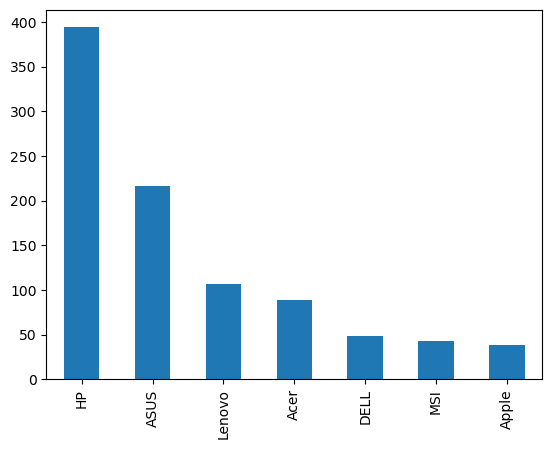

In [83]:
df["Brand"].value_counts().head(7).plot(kind = "bar")

<Axes: xlabel='Price', ylabel='Count'>

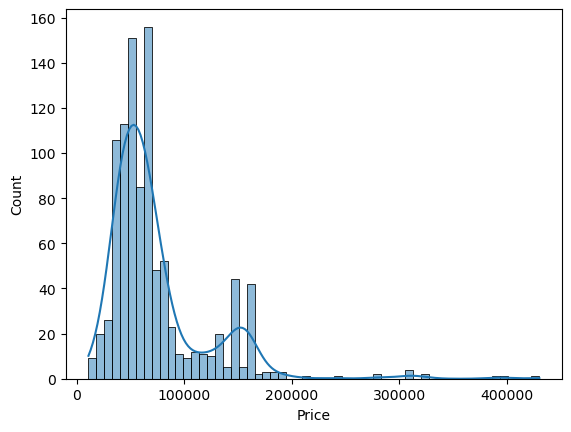

In [85]:
sns.histplot(x = df["Price"],kde = True, data = df)

<Axes: >

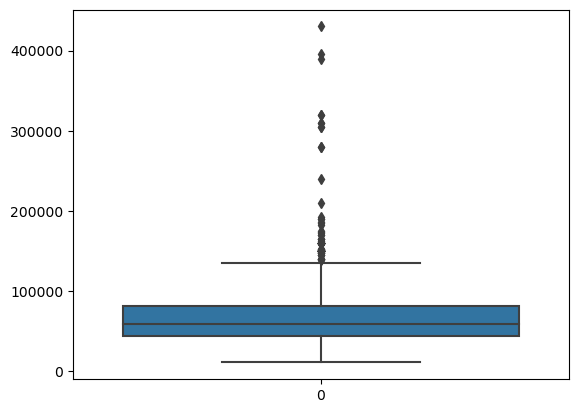

In [86]:
sns.boxplot(df["Price"])

In [88]:
q1 = df["Price"].quantile(0.25)
q3 = df["Price"].quantile(0.75)
iqr = q3 - q1
outliers = df[(df["Price"]<q1-1.5*iqr) | (df["Price"]>q3+1.5*iqr)]

<Axes: >

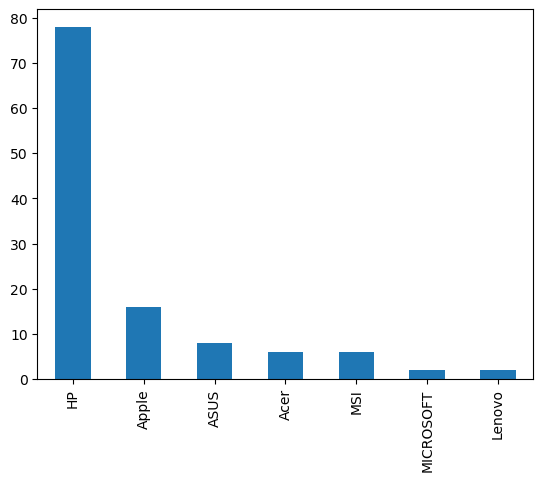

In [92]:
outliers["Brand"].value_counts().head(7).plot(kind = "bar")

In [ ]:
## Winsorzation
# lower_limit = df["Price"].quantile(0.05)
# upper_limit = df["Price"].quantile(0.95)
# df["Price"] = df["Price"].clip(lower = lower_limit,upper=upper_limit)
# sns.boxplot(df["Price"])

In [93]:
## Bivariate Analysis

<Axes: xlabel='Price', ylabel='rating'>

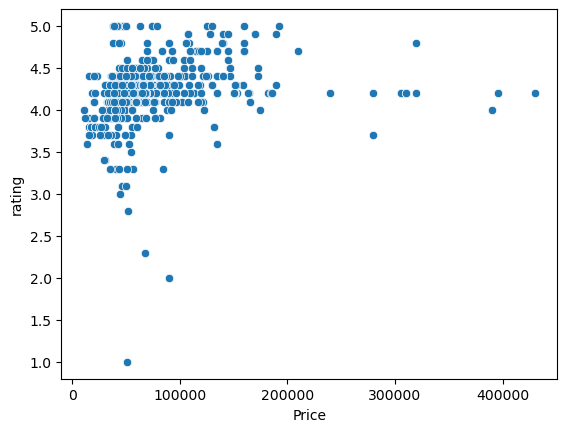

In [94]:
sns.scatterplot(x = "Price",y = "rating", data = df)

<Axes: xlabel='RAM', ylabel='Price'>

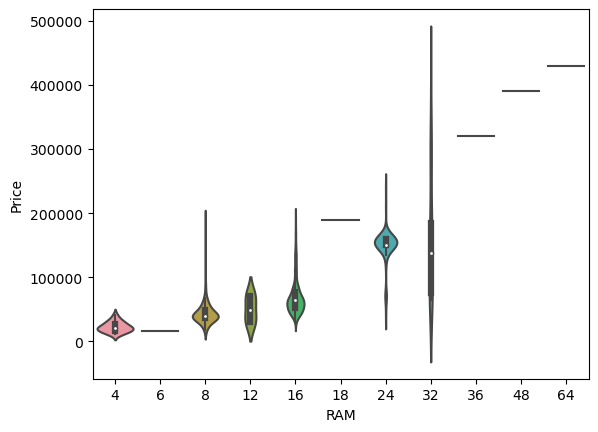

In [95]:
sns.violinplot(x = "RAM", y = "Price", data = df)

In [96]:
## Multivariate Analysis

<Axes: xlabel='Brand', ylabel='Price'>

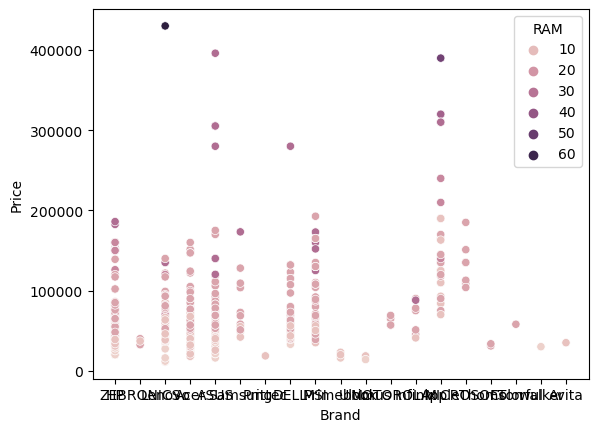

In [98]:
sns.scatterplot(x = "Brand", y = "Price", hue = "RAM", data = df)

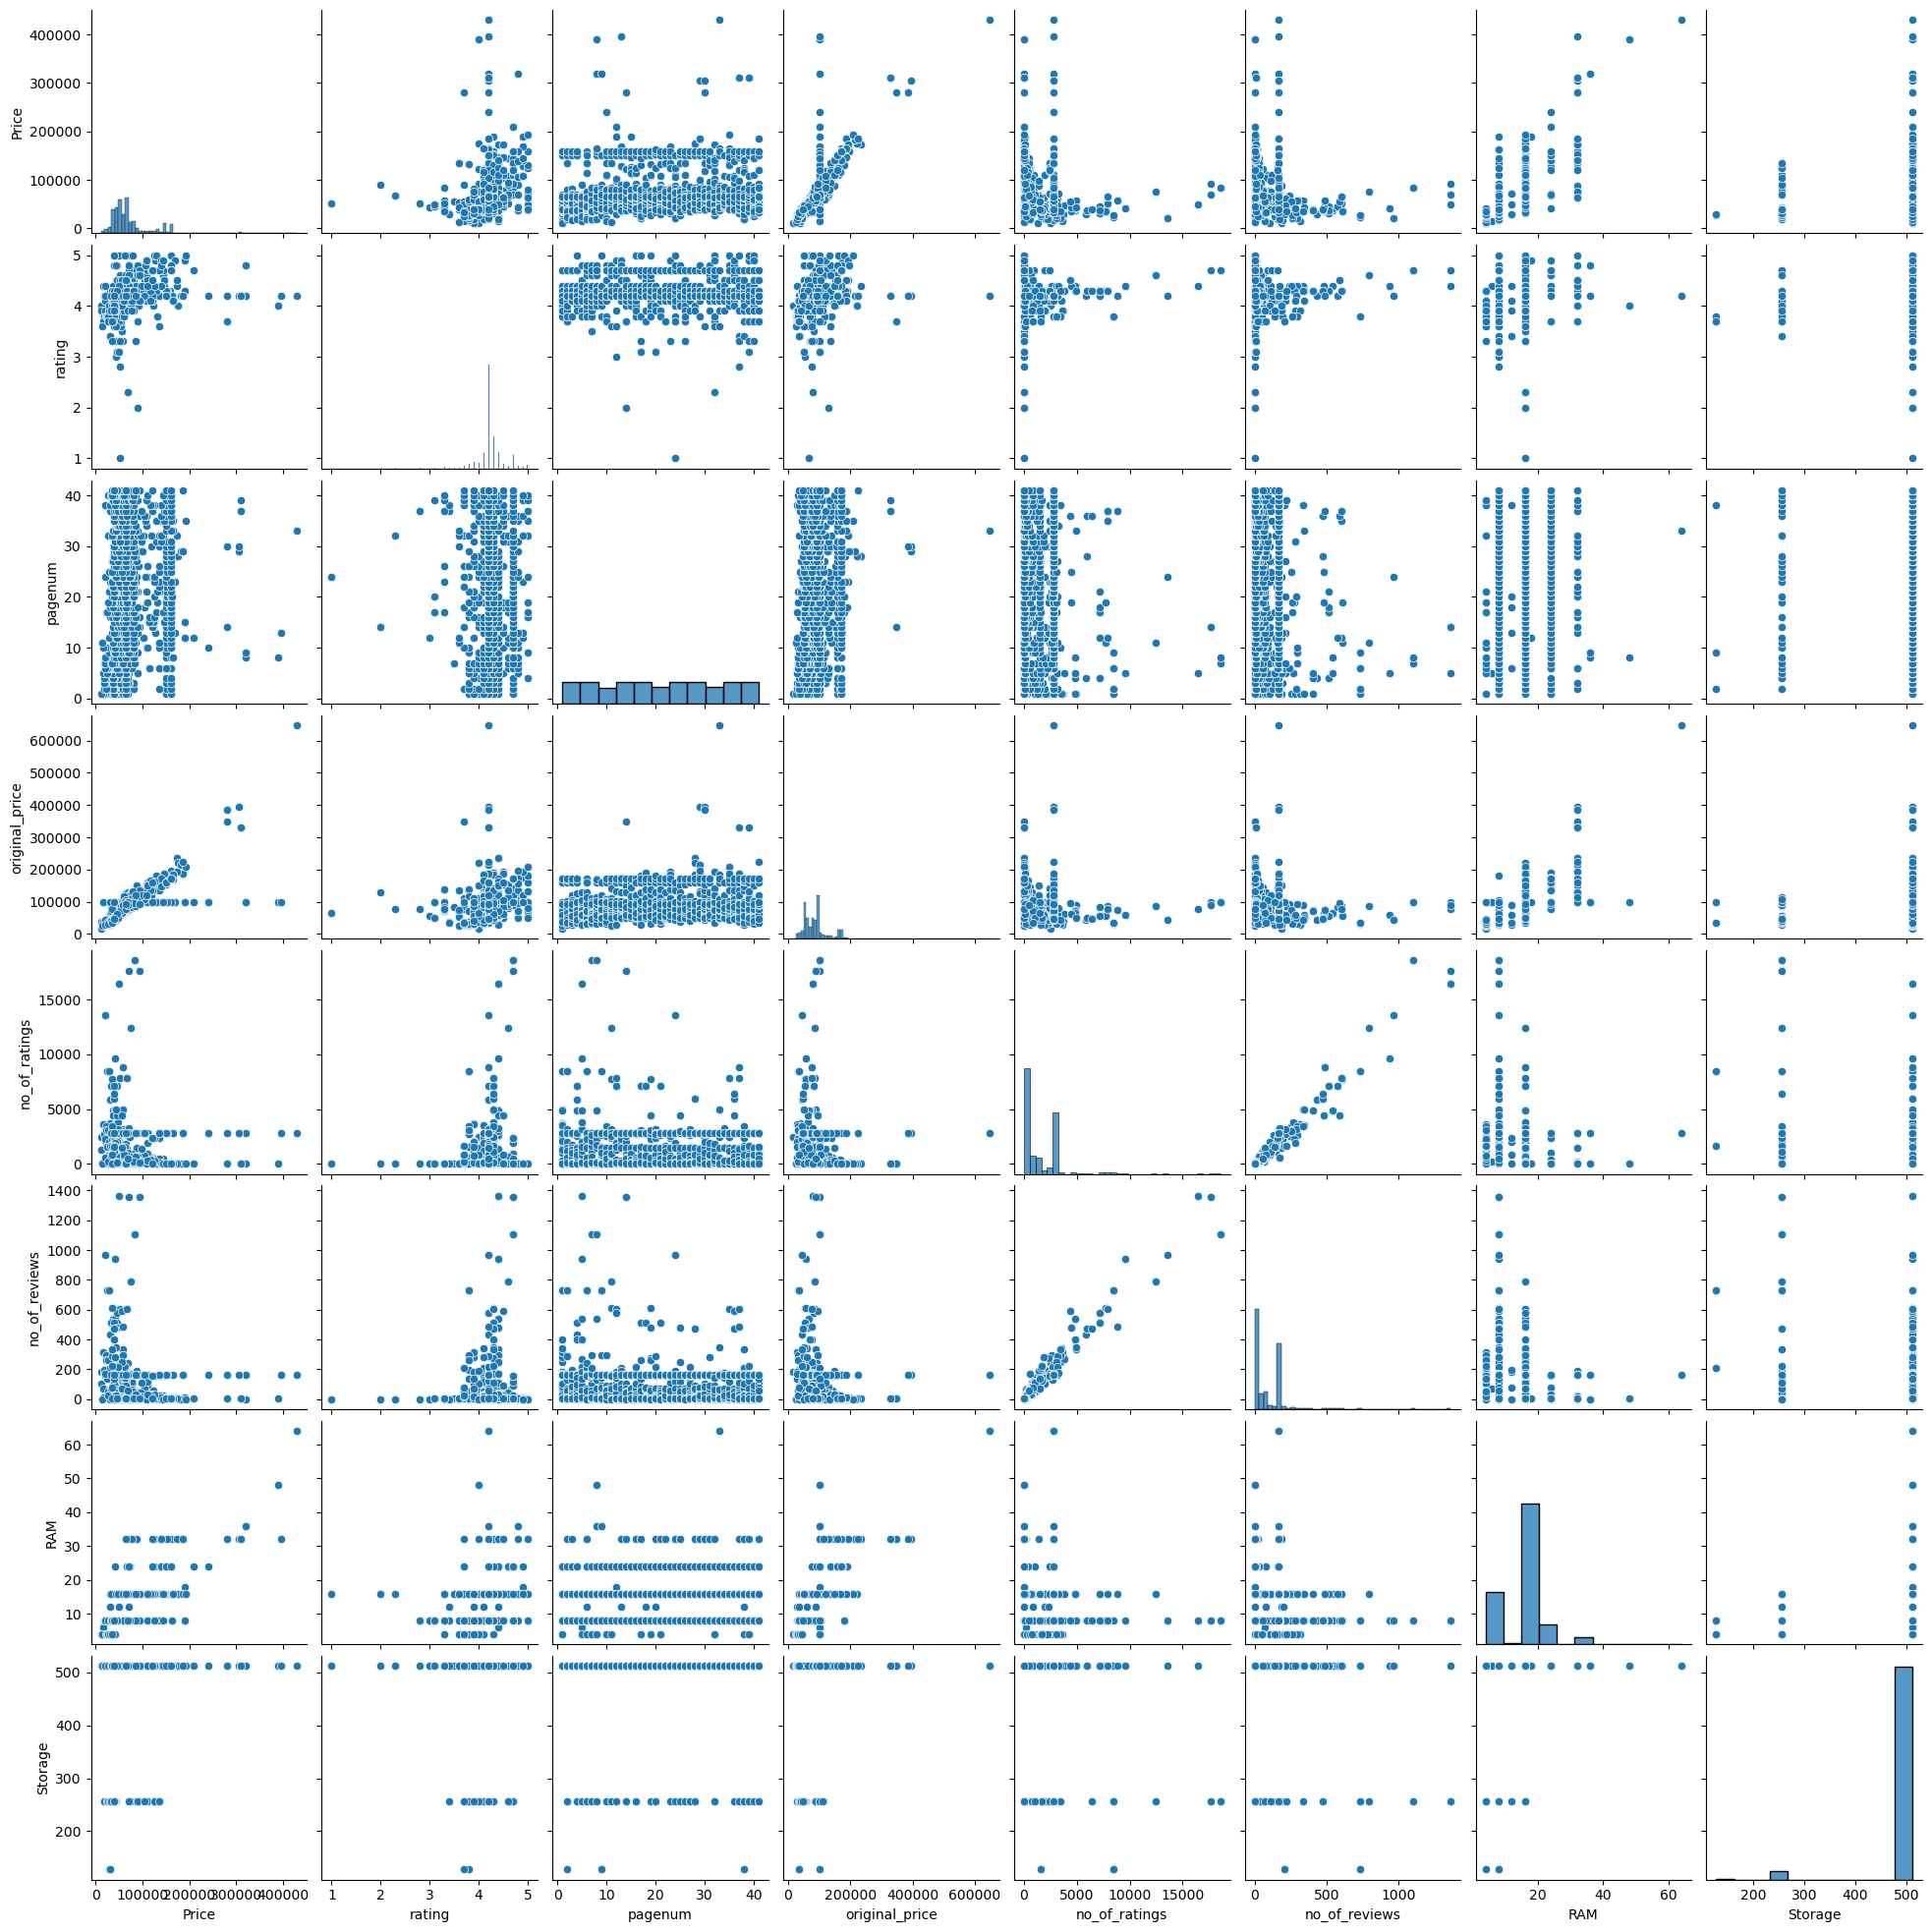

In [99]:
sns.pairplot(df)

<Axes: >

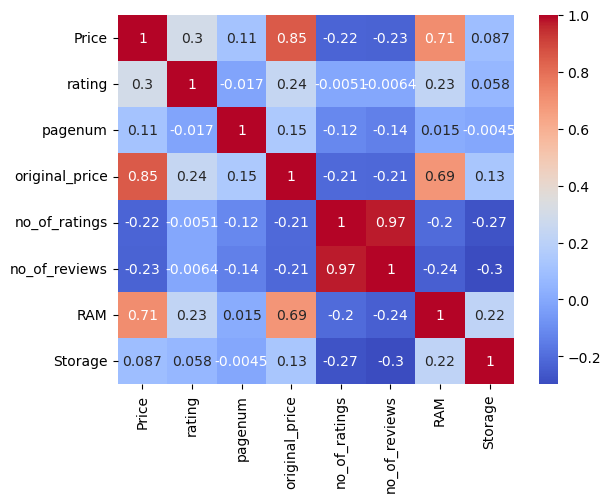

In [101]:
sns.heatmap(df.select_dtypes(include = ["int64","float64"]).corr(),annot = True, cmap = "coolwarm")